# Matrix Completion via Nuclear Norm

Matrix completion solves
$$
\min_X \frac12\|P_\Omega(X-M)\|_F^2 + \lambda \|X\|_*.
$$
The proximal step of $\|\cdot\|_*$ is singular-value soft-thresholding.
We recover a low-rank matrix from random missing entries.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/matrix-completion-nuclear-norm/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/matrix-completion-nuclear-norm") if Path("python/matrix-completion-nuclear-norm").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Matrix Completion via Nuclear Norm**, with equations and plots designed to expose both the model and the numerical behavior.


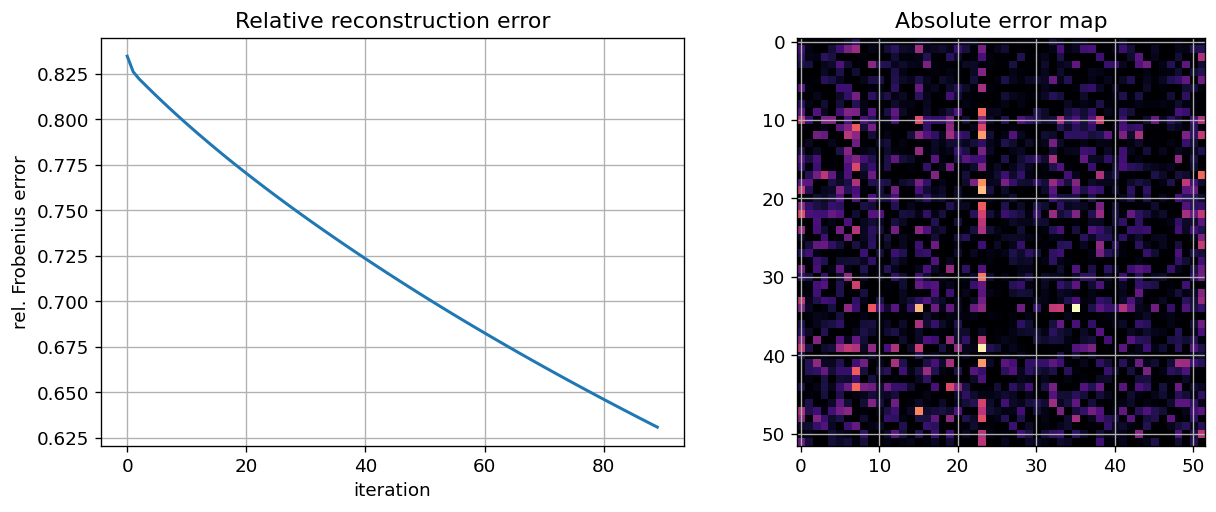

In [2]:
n = 52
r = 4
U = rng.normal(size=(n, r))
V = rng.normal(size=(n, r))
M = U @ V.T

mask = rng.uniform(size=(n, n)) < 0.3
Obs = np.where(mask, M, 0.0)

X = np.zeros((n, n))
lam = 0.22
tau = 1.2
errs = []

for _ in range(90):
    G = np.where(mask, X - Obs, 0.0)
    Y = X - tau * G
    Ux, s, Vx = np.linalg.svd(Y, full_matrices=False)
    s = np.maximum(s - lam * tau, 0.0)
    X = (Ux * s) @ Vx
    errs.append(np.linalg.norm(X - M, "fro") / np.linalg.norm(M, "fro"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(errs, lw=1.8)
axes[0].set_title("Relative reconstruction error")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("rel. Frobenius error")
axes[1].imshow(np.abs(M - X), cmap="magma")
axes[1].set_title("Absolute error map")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- E. J. Candès, B. Recht, "Exact Matrix Completion via Convex Optimization", Foundations of Computational Mathematics, 2009.
- J.-F. Cai, E. J. Candès, Z. Shen, "A Singular Value Thresholding Algorithm for Matrix Completion", SIAM J. Optim., 2010.
- B. Recht, M. Fazel, P. A. Parrilo, "Guaranteed Minimum-Rank Solutions via Nuclear Norm Minimization", SIAM Review, 2010.
